# Centriole labels colocalisation analysis.

This script will focus on the positional analysis of the centriole markers Centrin2 and CenSpark. The goal is to determine wherether Centrin2 and CenSpark label the centriole correct position or not. If both label are visible at the same location, then we can hypothesis that a centriole has been localized. 

In [160]:
import os
import time
import tifffile
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import product
from tqdm import tqdm
from pathlib import Path
from stardist.models import StarDist2D, StarDist3D
from csbdeep.utils import Path, normalize
from skimage.feature import blob_dog, blob_log, blob_doh
from skimage.filters import threshold_otsu

%matplotlib inline

## Data

In [162]:
IMG_PATH = r"K:\users\voland\Images\Cova_data\ZF_colocalisation\pre_processed\interpolation\interpolated_20260115CFHa_CetnGFP_CS_TL_4-6hpf_e4_t1-7.tif"

In [4]:
start_time = time.time()
tiff_img = tifffile.imread(IMG_PATH)
print(f"Openning the image took {(time.time() - start_time):.2f} seconds")

Openning the image took 12.33 seconds


In [5]:
start_time = time.time()
vol = tifffile.memmap(IMG_PATH)
print(f"Openning the image took {(time.time() - start_time):.2f} seconds")

Openning the image took 0.08 seconds


## Image analysis

Before going to deep in the semgentation pipeline, we need to analyse our image and better understand it.
Let's first start with some general analysis.

In [6]:
print(f"Image shape: {vol.shape}")
print(f"Min value: {vol.min()}")
print(f"Max value: {vol.max()}")
print(f"Mean value: {vol.mean():.1f}")

Image shape: (7, 80, 3, 768, 768)
Min value: 0
Max value: 255
Mean value: 16.4


The shape of the dataset corresponds to (T,Z,C,Y,X). 
With the following channel configuration: 
- C0: CenSpark (cyan)
- C1: Cetn2 (green)
- C2: Normal

As the image is in 3D, we can't analyse the entire dataset, however we could take one image that is quite representative of the type of data in it and analyse it.

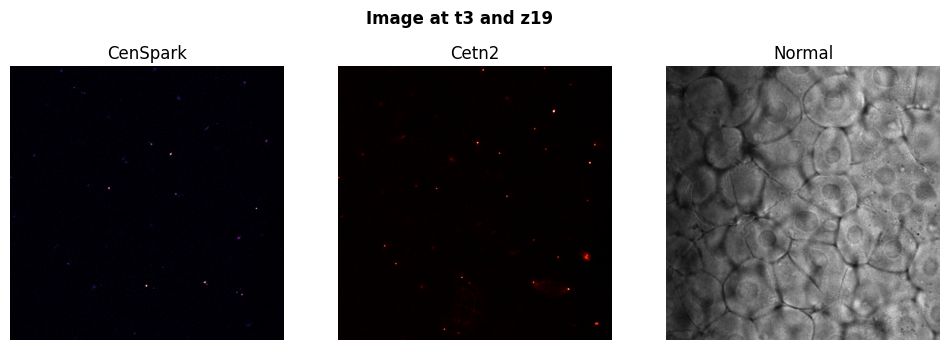

In [7]:
t = 3
z = 19
img = vol[t, z] #In Fiji this corresponds to the image ate t4 and z20
fig, axes = plt.subplots(1,3, figsize=(12,4))
axes[0].imshow(img[0], cmap="inferno")
axes[0].set_title("CenSpark")
axes[0].axis('off')
axes[1].imshow(img[1], cmap="gist_heat")
axes[1].set_title("Cetn2")
axes[1].axis("off")
axes[2].imshow(img[2], cmap="gray")
axes[2].set_title("Normal")
axes[2].axis("off")
fig.suptitle(f"Image at t{t} and z{z}", fontweight='bold')

plt.show()

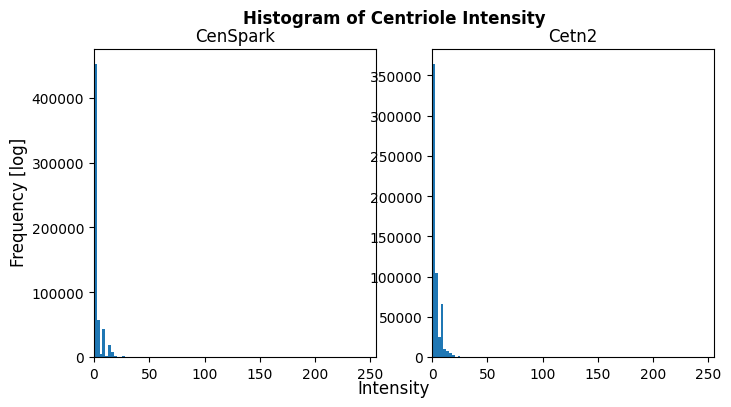

In [8]:
fig, axes = plt.subplots(1,2, figsize = (8,4))
axes[0].hist(img[0].flatten(), bins = 100)
axes[0].set_title('CenSpark')
axes[0].set_xlim(0, img.max())
axes[1].hist(img[1].flatten(), bins = 100)
axes[1].set_title('Cetn2')
axes[1].set_xlim(0, img.max())
fig.suptitle("Histogram of Centriole Intensity", fontweight='bold')
fig.supxlabel('Intensity')
fig.supylabel('Frequency [log]')
plt.show()

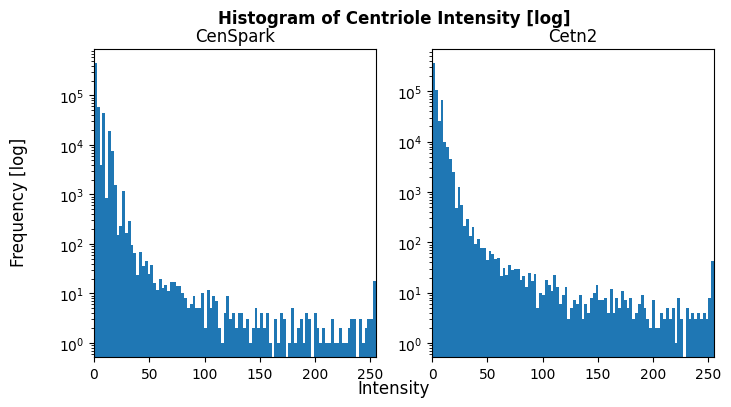

In [9]:
fig, axes = plt.subplots(1,2, figsize = (8,4))
axes[0].hist(img[0].flatten(), bins=100, log=True)
axes[0].set_title('CenSpark')
axes[0].set_xlim(0, img.max())
axes[1].hist(img[1].flatten(), bins=100, log=True)
axes[1].set_title('Cetn2')
axes[1].set_xlim(0, img.max())
fig.suptitle("Histogram of Centriole Intensity [log]", fontweight='bold')
fig.supxlabel('Intensity')
fig.supylabel('Frequency [log]')
plt.show()

These histograms reveals that the images is highly saturated, where our centrioles have very high pixel value compared to the background. This makes normalisation almost impossible.

## 3D segmentation

Different pipelines exist for 3D segmentation. As our image is way to saturated, we can't really use deep learning technics and traditional segmentation will just be more efficient.

In [150]:
img_CS = vol[5,:,1]
#plt.imshow(img_CS)

In [90]:
img_CS_z = img_CS[14]
blobs_log = blob_log(img_CS_z, max_sigma=4, threshold=0.2)

# Compute radii in the 3rd column.
blobs_log[:, 2] = blobs_log[:, 2] * math.sqrt(2)

blobs_dog = blob_dog(img_CS_z, max_sigma=6, threshold=0.15)
blobs_dog[:, 2] = blobs_dog[:, 2] * math.sqrt(2)

blobs_doh = blob_doh(img_CS_z, max_sigma=20, threshold=0.01)

In [92]:
blobs_log = blob_log(img_CS_z, max_sigma=4, threshold=0.2)

In [93]:
blobs_dog = blob_dog(img_CS_z, max_sigma=6, threshold=0.15)

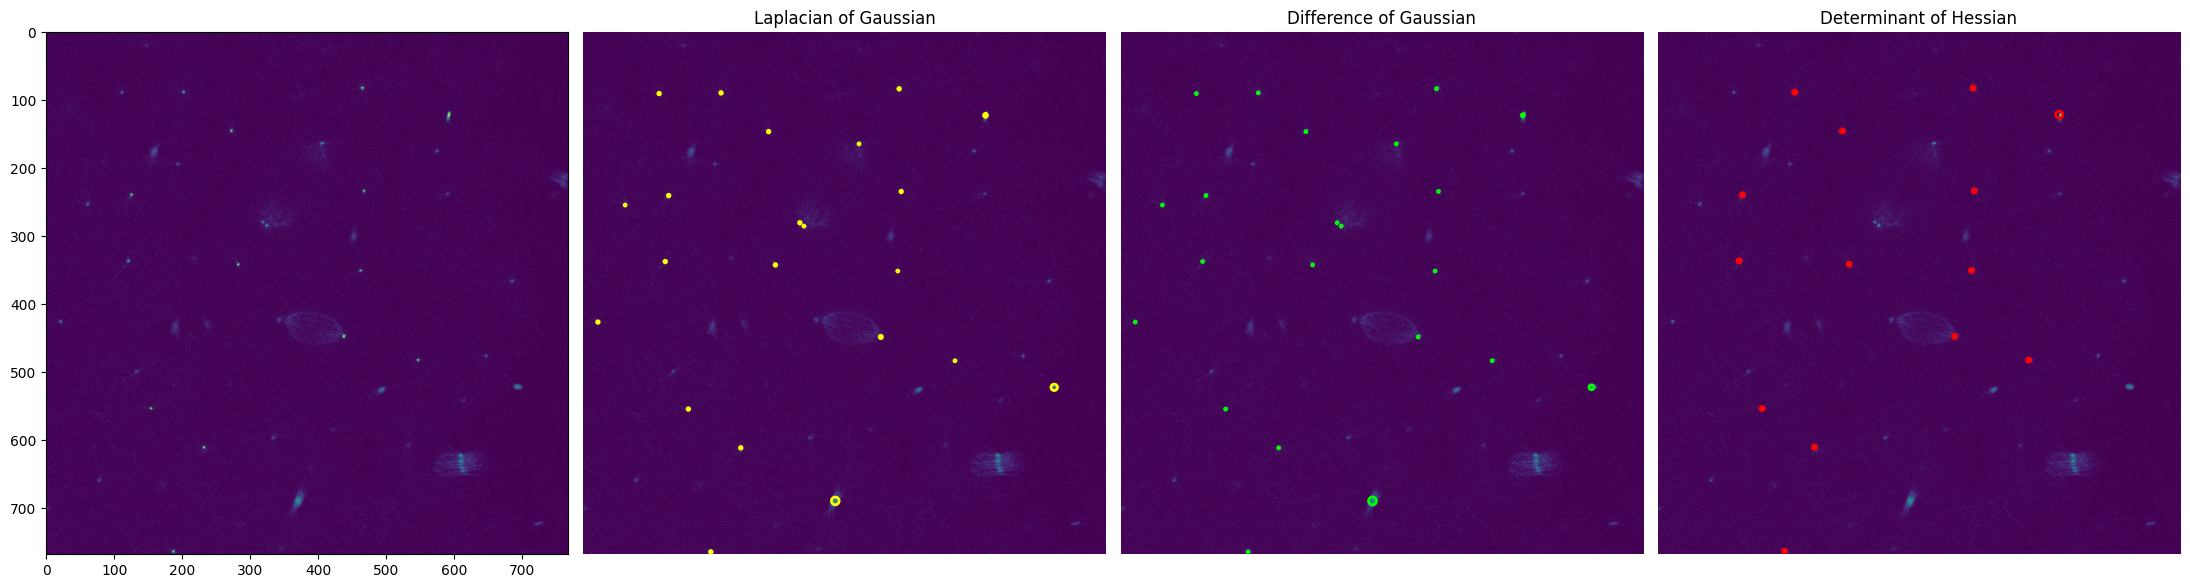

In [91]:
blobs_list = [blobs_log, blobs_dog, blobs_doh]
colors = ['yellow', 'lime', 'red']
titles = ['Laplacian of Gaussian', 'Difference of Gaussian', 'Determinant of Hessian']
sequence = zip(blobs_list, colors, titles)

fig, axes = plt.subplots(1, 4, figsize=(22, 8), sharex=True, sharey=True)
ax = axes.ravel()
ax[0].imshow(img_CS_z)

for idx, (blobs, color, title) in enumerate(sequence):
    ax[idx + 1].set_title(title)
    ax[idx + 1].imshow(img_CS_z)
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
        ax[idx +1].add_patch(c)
    ax[idx+1].set_axis_off()

plt.tight_layout()
plt.show()

In [95]:
blobs_dog = blob_dog(img_CS, max_sigma=6, threshold=0.15)

In [53]:
blobs_dog = blob_log(img_CS, max_sigma=4, threshold=0.2)

In [197]:
print(len(blobs_dog))
blobs_dog
new_array = np.column_stack([np.full(len(blobs_dog), 2), blobs_dog])
new_array

239


array([[  2.,  32., 743., 428.,   1.],
       [  2.,  35., 560., 605.,   1.],
       [  2.,  19.,  45., 665.,   1.],
       ...,
       [  2.,  58., 276., 103.,   1.],
       [  2.,  13., 646., 612.,   1.],
       [  2.,  79., 104.,   5.,   1.]], shape=(239, 5))

In [201]:
np.concatenate([new_array,new_array])

array([[  2.,  32., 743., 428.,   1.],
       [  2.,  35., 560., 605.,   1.],
       [  2.,  19.,  45., 665.,   1.],
       ...,
       [  2.,  58., 276., 103.,   1.],
       [  2.,  13., 646., 612.,   1.],
       [  2.,  79., 104.,   5.,   1.]], shape=(478, 5))

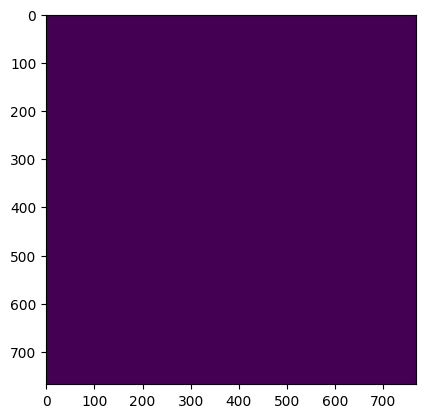

In [66]:
test = np.zeros((768,768))
plt.imshow(test)

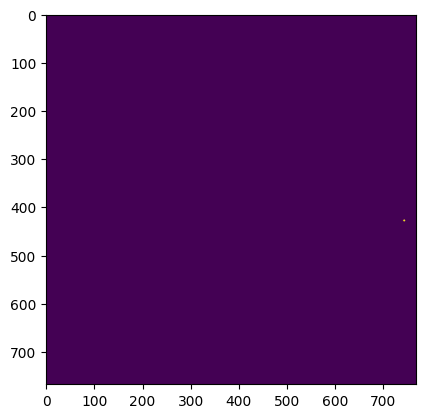

In [67]:
cv2.circle(test, center=(743, 428), radius=2, color=(255, 255, 255), thickness=-1)
plt.imshow(test)

In [ ]:
stack = np.zeros((80,768,768),dtype=np.uint8)
for p in blobs_dog:
    [z, y, x, r] = p
    [z,y,x] = [int(z),int(y),int(x)]
    r = max(2, int(r))  # Minimum radius of 2 pixels

    #if (z-1 >=0): cv2.circle(stack[z - 1], center=(x,y), radius=1, color=200, thickness=-1)
    cv2.circle(stack[z], center=(x,y), radius=2, color=200, thickness=-1)
    #if (z+1 < 80 ): cv2.circle(stack[z+1], center=(x,y), radius=1, color=200, thickness=-1)
    

In [ ]:
[z, y, x] = img_CS.shape
matchup = np.empty((z,2,y,x), dtype = 'uint8')
for z in range(img_CS.shape[0]):
    matchup[z] = [np.array(img_CS[z]), stack[z]]

array([[[[0, 0, 0, ..., 0, 0, 0],
         [1, 3, 0, ..., 0, 0, 0],
         [0, 1, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]],


       [[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 8, 0, 0],
         ...,
         [0, 0, 8, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]],

        [[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]]],


       [[[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 5, 2],
         ...,


In [142]:
output =  r"K:\users\voland\Images\Cova_data\ZF_colocalisation\results\center_20260115CFHa_CetnGFP_CS_TL_4-6hpf_e4_t1-7.tif"
tifffile.imwrite(output, matchup, imagej= True)

In [219]:
output =  r"K:\users\voland\Images\Cova_data\ZF_colocalisation\results\center_20260115CFHa_CetnGFP_CS_TL_4-6hpf_e4_t1-7.csv"

blobs_df = pd.DataFrame(blobs_dog, columns = ["Z", "Y", "X", "R"])
blobs_df.to_csv(output)

In [226]:
center_coord = np.column_stack([np.full(len(blobs_dog), 2), blobs_dog])
center_coord

array([[  2.,  32., 743., 428.,   1.],
       [  2.,  35., 560., 605.,   1.],
       [  2.,  19.,  45., 665.,   1.],
       ...,
       [  2.,  58., 276., 103.,   1.],
       [  2.,  13., 646., 612.,   1.],
       [  2.,  79., 104.,   5.,   1.]], shape=(239, 5))

In [238]:
test =[]
test.append(center_coord)
test != []

True

In [ ]:
blobs_df.insert(0,"T",1)
blobs_df

,T,Z,Y,X,R
0,1,32.0,743.0,428.0,1.0
1,1,35.0,560.0,605.0,1.0
2,1,19.0,45.0,665.0,1.0
3,1,11.0,422.0,344.0,1.0
4,1,15.0,342.0,282.0,1.0
...,...,...,...,...,...
234,1,73.0,507.0,128.0,1.0
235,1,55.0,543.0,728.0,1.0
236,1,58.0,276.0,103.0,1.0
237,1,13.0,646.0,612.0,1.0


In [184]:
blobs_df2 = blobs_df
pd.concat([blobs_df,blobs_df2])

,T,Z,Y,X,R
0,1,32.0,743.0,428.0,1.0
1,1,35.0,560.0,605.0,1.0
2,1,19.0,45.0,665.0,1.0
3,1,11.0,422.0,344.0,1.0
4,1,15.0,342.0,282.0,1.0
...,...,...,...,...,...
234,1,73.0,507.0,128.0,1.0
235,1,55.0,543.0,728.0,1.0
236,1,58.0,276.0,103.0,1.0
237,1,13.0,646.0,612.0,1.0


In [ ]:
pd.DataFrame(
    [[str(input), 2, None, "test", 1, 2]],
    columns=["Input path", "Channel", "Time", "Algorithm", "Max_sigma", "Threshold"]
)

,Input path,Channel,Time,Algorithm,Max_sigma,Threshold
0,<method-wrapper '__str__' of method object at ...,2,None,test,1,2
